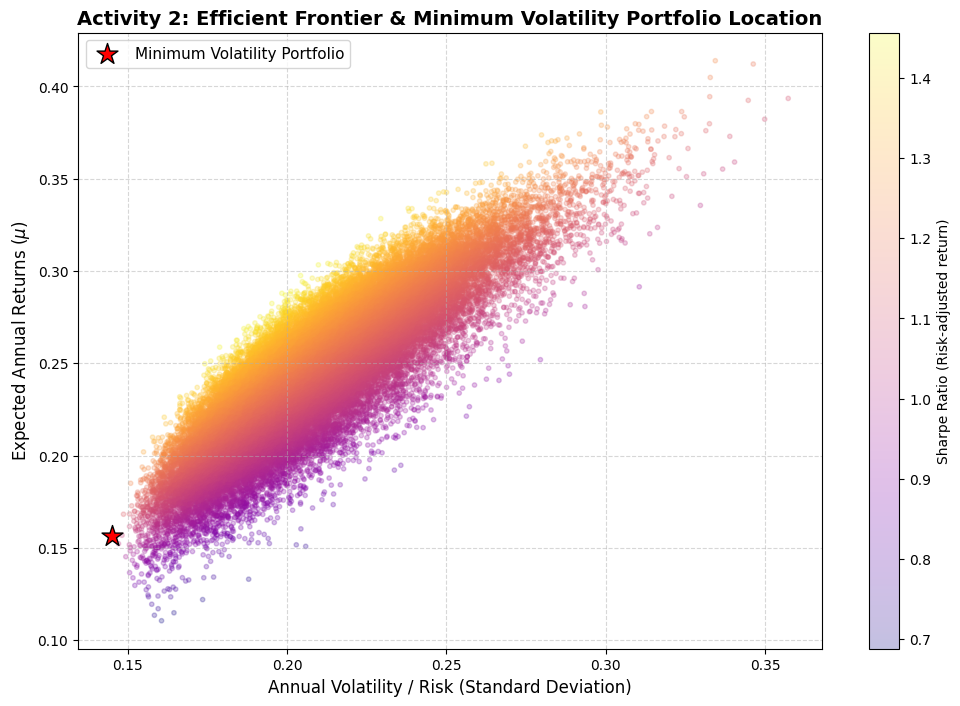


     MINIMUM VOLATILITY PORTFOLIO ALLOCATION     
NVIDIA          :   5.50%
AMAZON          :   4.14%
ALPHABET        :   5.58%
META            :   2.63%
J&J             :  24.39%
JPM             :   4.54%
COCA-COLA       :  26.48%
EXXON MOBILE    :  13.36%
P&G             :  13.38%
--------------------------------------------------
Expected Portfolio Return : 15.65%
Minimum Risk (Volatility) : 14.50%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as sco

# 1. Load the data (Ensure 'CS2_s17349new.xlsx' is uploaded to Colab)
file_name = 'CS2_s17349new.xlsx'

# --- Clean and Extract Covariance Matrix ---
cov_df = pd.read_excel(file_name, sheet_name='Efficient Frontier', skiprows=2, index_col=0)

# Strip whitespace and standardize naming to uppercase for index and columns
cov_df.index = cov_df.index.str.strip().str.upper()
cov_df.columns = cov_df.columns.str.strip().str.upper()

# Handle specific typo variations from your sheet mapping to correct tickers
rename_dict = {
    'AMAZONE': 'AMAZON',
    'EXXOM MOBILE': 'EXXON MOBILE',
    'EXXEN MOBILE': 'EXXON MOBILE',
    'APPL': 'AAPL'
}
cov_df = cov_df.rename(index=rename_dict, columns=rename_dict)

# Canonical list of tickers we expect to use in uppercase
tickers = ['NVIDIA', 'AAPL', 'AMAZON', 'ALPHABET', 'META', 'J&J', 'JPM', 'COCA-COLA', 'EXXON MOBILE', 'P&G']

# Slice exactly the 10x10 matrix needed
cov_matrix = cov_df.loc[tickers, tickers].astype(float).values

# --- Clean and Extract Expected Annual Returns (Mu) ---
mc_df = pd.read_excel(file_name, sheet_name='Monte Calo Simulation', skiprows=0, index_col=0)
mc_df.columns = mc_df.columns.str.strip().str.upper()
mc_df = mc_df.rename(columns=rename_dict)

# Extract the returns row
mc_df.index = mc_df.index.str.strip()
returns_row = mc_df.loc['Mu(Annual return)']

# Extract returns matching our strict ticker order
annual_returns = np.array([returns_row[t] for t in tickers], dtype=float)
num_assets = len(tickers)

# 2. Define functions for portfolio performance
def portfolio_performance(weights, returns, cov_matrix):
    port_return = np.sum(returns * weights)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return port_return, port_volatility

# 3. Optimization to find the absolute Minimum Volatility Portfolio
def minimize_volatility(weights):
    return portfolio_performance(weights, annual_returns, cov_matrix)[1]

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}) # Weights must sum to 1
bounds = tuple((0, 1) for asset in range(num_assets))       # No short-selling (0% to 100%)
initializer = num_assets * [1. / num_assets,]

opt_result = sco.minimize(minimize_volatility, initializer, method='SLSQP', bounds=bounds, constraints=constraints)
min_vol_weights = opt_result['x']
min_vol_ret, min_vol_vol = portfolio_performance(min_vol_weights, annual_returns, cov_matrix)

# 4. Generate Random Portfolios to map out the Efficient Frontier space
num_portfolios = 50000
results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights) # Normalize to sum to 1
    weights_record.append(weights)
    p_ret, p_vol = portfolio_performance(weights, annual_returns, cov_matrix)
    results[0,i] = p_vol
    results[1,i] = p_ret
    results[2,i] = p_ret / p_vol # Sharpe Ratio

# 5. Plotting the Efficient Frontier
plt.figure(figsize=(12, 8))
# Plot the cloud of random portfolios colored by Sharpe Ratio
sc = plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='plasma', marker='o', s=10, alpha=0.25)
plt.colorbar(sc, label='Sharpe Ratio (Risk-adjusted return)')

# Highlight the Minimum Volatility Portfolio
plt.scatter(min_vol_vol, min_vol_ret, color='red', marker='*', s=250, edgecolors='black', label='Minimum Volatility Portfolio')

plt.title('Activity 2: Efficient Frontier & Minimum Volatility Portfolio Location', fontsize=14, fontweight='bold')
plt.xlabel('Annual Volatility / Risk (Standard Deviation)', fontsize=12)
plt.ylabel('Expected Annual Returns ($\mu$)', fontsize=12)
plt.legend(loc='upper left', labelspacing=1.2, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Display optimal weights output
print("\n" + "="*50)
print("     MINIMUM VOLATILITY PORTFOLIO ALLOCATION     ")
print("="*50)
for ticker, weight in zip(tickers, min_vol_weights):
    if weight > 0.0001: # Filter out near-zero allocations for clarity
        print(f"{ticker:<15} : {weight*100:6.2f}%")
print("-"*50)
print(f"Expected Portfolio Return : {min_vol_ret*100:.2f}%")
print(f"Minimum Risk (Volatility) : {min_vol_vol*100:.2f}%")
print("="*50)

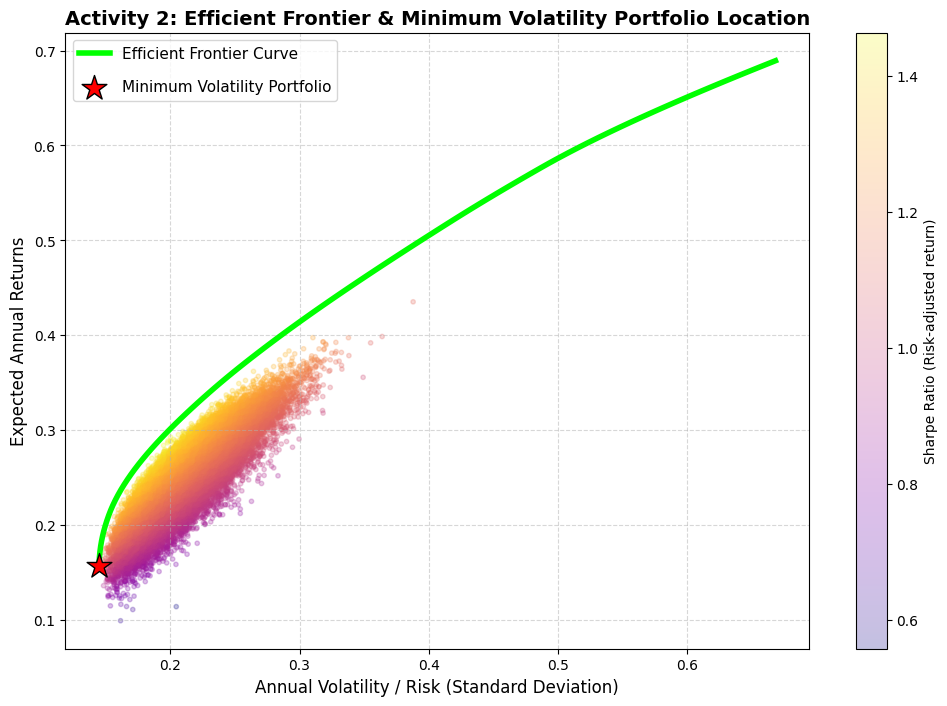


     MINIMUM VOLATILITY PORTFOLIO ALLOCATION     
NVIDIA          :   5.50%
AMAZON          :   4.14%
ALPHABET        :   5.58%
META            :   2.63%
J&J             :  24.39%
JPM             :   4.54%
COCA-COLA       :  26.48%
EXXON MOBILE    :  13.36%
P&G             :  13.38%
--------------------------------------------------
Expected Portfolio Return : 15.65%
Minimum Risk (Volatility) : 14.50%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as sco

# 1. Load the data (Ensure 'CS2_s17349new.xlsx' is uploaded to Colab)
file_name = 'CS2_s17349new.xlsx'

# --- Clean and Extract Covariance Matrix ---
cov_df = pd.read_excel(file_name, sheet_name='Efficient Frontier', skiprows=2, index_col=0)

# Strip whitespace and standardize naming to uppercase for index and columns
cov_df.index = cov_df.index.astype(str).str.strip().str.upper()
cov_df.columns = cov_df.columns.astype(str).str.strip().str.upper()

# Handle specific typo variations from your sheet mapping to correct tickers
rename_dict = {
    'AMAZONE': 'AMAZON',
    'EXXOM MOBILE': 'EXXON MOBILE',
    'EXXEN MOBILE': 'EXXON MOBILE',
    'APPL': 'AAPL'
}
cov_df = cov_df.rename(index=rename_dict, columns=rename_dict)

# Canonical list of tickers we expect to use in uppercase
tickers = ['NVIDIA', 'AAPL', 'AMAZON', 'ALPHABET', 'META', 'J&J', 'JPM', 'COCA-COLA', 'EXXON MOBILE', 'P&G']

# Slice exactly the 10x10 matrix needed
cov_matrix = cov_df.loc[tickers, tickers].astype(float).values

# --- Clean and Extract Expected Annual Returns (Mu) ---
mc_df = pd.read_excel(file_name, sheet_name='Monte Calo Simulation', skiprows=0, index_col=0)
mc_df.columns = mc_df.columns.astype(str).str.strip().str.upper()
mc_df = mc_df.rename(columns=rename_dict)

# Extract the returns row
mc_df.index = mc_df.index.astype(str).str.strip()
returns_row = mc_df.loc['Mu(Annual return)']

# Extract returns matching our strict ticker order
annual_returns = np.array([returns_row[t] for t in tickers], dtype=float)
num_assets = len(tickers)

# 2. Define functions for portfolio performance
def portfolio_performance(weights, returns, cov_matrix):
    port_return = np.sum(returns * weights)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return port_return, port_volatility

# 3. Optimization to find the absolute Minimum Volatility Portfolio
def minimize_volatility(weights):
    return portfolio_performance(weights, annual_returns, cov_matrix)[1]

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}) # Weights must sum to 1
bounds = tuple((0, 1) for asset in range(num_assets))       # No short-selling (0% to 100%)
initializer = num_assets * [1. / num_assets,]

opt_result = sco.minimize(minimize_volatility, initializer, method='SLSQP', bounds=bounds, constraints=constraints)
min_vol_weights = opt_result['x']
min_vol_ret, min_vol_vol = portfolio_performance(min_vol_weights, annual_returns, cov_matrix)

# 4. Generate Random Portfolios to map out the Efficient Frontier space (Scatter Plot)
num_portfolios = 50000
results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights) # Normalize to sum to 1
    p_ret, p_vol = portfolio_performance(weights, annual_returns, cov_matrix)
    results[0,i] = p_vol
    results[1,i] = p_ret
    results[2,i] = p_ret / p_vol # Sharpe Ratio

# 5. Calculate the Efficient Frontier Marginal Curve
# Generate target returns from the min vol return to the max single asset return
target_returns = np.linspace(min_vol_ret, annual_returns.max(), 100)
efficient_vols = []

for tr in target_returns:
    # Constraints: Weights sum to 1 AND return equals the target return (tr)
    ef_constraints = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: portfolio_performance(x, annual_returns, cov_matrix)[0] - tr}
    )
    # Minimize volatility for this specific target return
    ef_result = sco.minimize(minimize_volatility, initializer, method='SLSQP', bounds=bounds, constraints=ef_constraints)
    efficient_vols.append(ef_result.fun)

# 6. Plotting the Efficient Frontier
plt.figure(figsize=(12, 8))

# Plot the cloud of random portfolios colored by Sharpe Ratio
sc = plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='plasma', marker='o', s=10, alpha=0.25)
plt.colorbar(sc, label='Sharpe Ratio (Risk-adjusted return)')

# Plot the Efficient Frontier Marginal Curve
plt.plot(efficient_vols, target_returns, color='lime', linewidth=4, label='Efficient Frontier Curve')

# Highlight the Minimum Volatility Portfolio
plt.scatter(min_vol_vol, min_vol_ret, color='red', marker='*', s=350, edgecolors='black', zorder=5, label='Minimum Volatility Portfolio')

plt.title('Activity 2: Efficient Frontier & Minimum Volatility Portfolio Location', fontsize=14, fontweight='bold')
plt.xlabel('Annual Volatility / Risk (Standard Deviation)', fontsize=12)
plt.ylabel('Expected Annual Returns', fontsize=12)
plt.legend(loc='upper left', labelspacing=1.2, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Display optimal weights output
print("\n" + "="*50)
print("     MINIMUM VOLATILITY PORTFOLIO ALLOCATION     ")
print("="*50)
for ticker, weight in zip(tickers, min_vol_weights):
    if weight > 0.0001: # Filter out near-zero allocations for clarity
        print(f"{ticker:<15} : {weight*100:6.2f}%")
print("-"*50)
print(f"Expected Portfolio Return : {min_vol_ret*100:.2f}%")
print(f"Minimum Risk (Volatility) : {min_vol_vol*100:.2f}%")
print("="*50)